In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
df = pd.read_csv("bank_personal_loan_data.csv")
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,0


In [3]:
df.shape

(5000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
 13  Personal Loan       5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [5]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
Personal Loan         0
dtype: int64

In [6]:
df = df.drop(columns=["ID", "ZIP Code"]) # Remove non-informative features
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,25,1,49,4,1.6,1,0,1,0,0,0,0
1,45,19,34,3,1.5,1,0,1,0,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,1,0


In [7]:
X_cluster = df.drop('Personal Loan', axis=1)
scaler = StandardScaler() # Standardize features before clustering
X_scaled = scaler.fit_transform(X_cluster)

In [8]:
# Determine optimal number of clusters
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1416
K = 3, Silhouette Score = 0.1597
K = 4, Silhouette Score = 0.1653
K = 5, Silhouette Score = 0.1505
K = 6, Silhouette Score = 0.1426
K = 7, Silhouette Score = 0.1389
K = 8, Silhouette Score = 0.1626
K = 9, Silhouette Score = 0.1632
K = 10, Silhouette Score = 0.1612


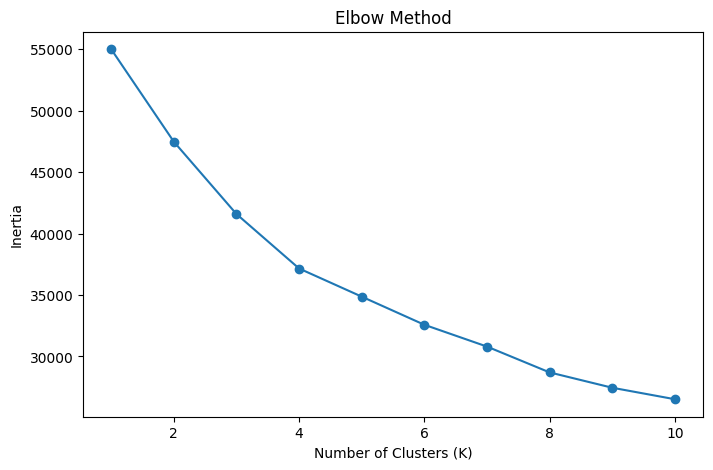

In [9]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [11]:
df['Cluster'] = clusters
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan,Cluster
0,25,1,49,4,1.6,1,0,1,0,0,0,0,3
1,45,19,34,3,1.5,1,0,1,0,0,0,0,3
2,39,15,11,1,1.0,1,0,0,0,0,0,0,3
3,35,9,100,1,2.7,2,0,0,0,0,0,0,3
4,35,8,45,4,1.0,2,0,0,0,0,1,0,3


In [12]:
df['Cluster'].value_counts()

Cluster
1    2024
3    1935
2     739
0     302
Name: count, dtype: int64

In [13]:
df.groupby('Cluster').mean()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
Cluster,,,,,,,,,,,,
0,45.701987,20.572848,104.589404,2.460265,2.878974,1.927152,92.324503,0.486755,1.0,0.937086,0.794702,0.463576
1,55.590909,30.269763,57.023715,2.394269,1.345257,1.978755,43.116601,0.077569,0.0,0.597826,0.279644,0.033103
2,43.688769,18.694181,144.564276,1.828146,4.653938,1.393775,110.772666,0.062246,0.0,0.543978,0.204330,0.284168
3,35.187597,9.937468,59.450129,2.605685,1.373736,1.957623,44.177261,0.088889,0.0,0.562791,0.265116,0.032558


In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

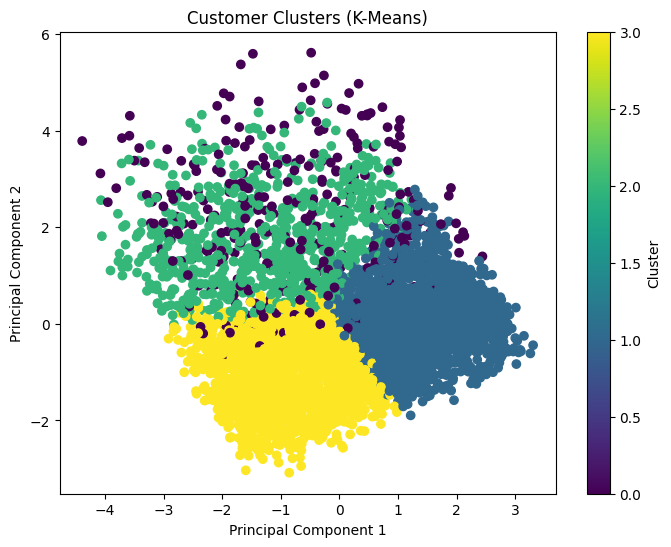

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Clusters (K-Means)')
plt.colorbar(label='Cluster')
plt.show()

In [16]:
# Remove clustering labels
model_df = df.drop(columns=['Cluster'], errors='ignore')

# Features and target
X = model_df.drop(columns=['Personal Loan'])
y = model_df['Personal Loan']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [20]:
print("KNN Accuracy:")
print(accuracy_score(y_test, y_pred_knn))

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy:
0.96

KNN Confusion Matrix:
[[900   4]
 [ 36  60]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       904
           1       0.94      0.62      0.75        96

    accuracy                           0.96      1000
   macro avg       0.95      0.81      0.86      1000
weighted avg       0.96      0.96      0.96      1000



In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

ann = Sequential()

ann.add(Input(shape=(X_train_scaled.shape[1],)))
ann.add(Dense(16, activation='relu'))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

In [22]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = ann.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8203 - loss: 0.4802 - val_accuracy: 0.9200 - val_loss: 0.2913
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9072 - loss: 0.2458 - val_accuracy: 0.9200 - val_loss: 0.1925
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9212 - loss: 0.1864 - val_accuracy: 0.9413 - val_loss: 0.1568
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9381 - loss: 0.1568 - val_accuracy: 0.9613 - val_loss: 0.1356
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9544 - loss: 0.1362 - val_accuracy: 0.9663 - val_loss: 0.1220
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9584 - loss: 0.1217 - val_accuracy: 0.9725 - val_loss: 0.1126
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9616 - loss: 0.1106 - val_accuracy: 0.9700 - val_loss: 0.1067
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9656 - loss: 0.1018 - val_accuracy: 0.

In [24]:
loss, accuracy = ann.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("ANN Accuracy:")
print(accuracy)

ANN Accuracy:
0.9769999980926514


In [25]:
y_pred_ann = ann.predict(X_test_scaled)

y_pred_ann = (y_pred_ann > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [26]:
print("\nANN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

print("\nANN Classification Report:")
print(classification_report(y_test, y_pred_ann))


ANN Confusion Matrix:
[[892  12]
 [ 11  85]]

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       904
           1       0.88      0.89      0.88        96

    accuracy                           0.98      1000
   macro avg       0.93      0.94      0.93      1000
weighted avg       0.98      0.98      0.98      1000



In [27]:
comparison = pd.DataFrame({
    'Model': ['KNN', 'ANN'],
    'Accuracy': [0.96, 0.977],
    'Precision': [0.94, 0.88],
    'Recall': [0.62, 0.89],
    'F1-Score': [0.75, 0.88]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.960,0.94,0.62,0.75
1,ANN,0.977,0.88,0.89,0.88
